# Model-1 MobileNetV3


In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from torchinfo import summary
from torch.utils.data import DataLoader
import time 

import sys
sys.path.append("..")
from utils.metrics import evaluate_model,compare_splits

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda


In [ ]:
DATA_PATH = "../dataset/processed"
MODEL_PATH = "../models"

os.makedirs(MODEL_PATH, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4

# Loading Data

In [3]:
transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),transforms.ToTensor(),])

train_data = datasets.ImageFolder(os.path.join(DATA_PATH, "train"),transform=transform)
val_data = datasets.ImageFolder(os.path.join(DATA_PATH, "val"),transform=transform)
test_data = datasets.ImageFolder(os.path.join(DATA_PATH, "test"),transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_data.classes)
print("Classes :", NUM_CLASSES)

Classes : 38


# Loading Model 

In [4]:
weights = MobileNet_V3_Small_Weights.DEFAULT
model = mobilenet_v3_small(weights=weights)

for param in model.parameters():
    param.requires_grad = False

model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),lr=LR)

In [5]:
print(summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE)))

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 38]                   --
├─Sequential: 1-1                                  [1, 576, 7, 7]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 16, 112, 112]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 112, 112]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 56, 56]           --
│    │    └─Sequential: 3-4                        [1, 16, 56, 56]           (744)
│    └─InvertedResidual: 2-3                       [1, 24, 28, 28]           --
│    │    └─Sequential: 3-5                        [1, 24, 28, 28]           (3,864)
│    └─InvertedResidual: 2-4                       [1, 24, 28, 28]           --
│    │    └─Sequential

# Model Training

In [6]:
print("\n" + "="*60)
print("\t\t    TRAINING STARTED")
print("="*60 + "\n")
total_time=0

for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    val_metrics = evaluate_model(model,val_loader,device,show=False)
    val_acc = val_metrics["Accuracy"]
    t = time.time() - start
    total_time+=t

    print(
        f"[Epoch {epoch+1:02d}/{EPOCHS}] "
        f"Loss={avg_loss:.4f}  "
        f"ValAcc={val_acc:.4f}  "
        f"Time={t:.2f}s"
    )

print("\n Training Finished \n")
print(f"Total Time Taken : {total_time:.2f}s")
print(f"Average Time Taken per epoch : {(total_time/EPOCHS):.2f}s")


		    TRAINING STARTED

[Epoch 01/10] Loss=1.4912  ValAcc=0.8870  Time=68.04s
[Epoch 02/10] Loss=0.5437  ValAcc=0.9187  Time=53.33s
[Epoch 03/10] Loss=0.3789  ValAcc=0.9308  Time=48.95s
[Epoch 04/10] Loss=0.3075  ValAcc=0.9379  Time=77.36s
[Epoch 05/10] Loss=0.2658  ValAcc=0.9422  Time=72.52s
[Epoch 06/10] Loss=0.2377  ValAcc=0.9482  Time=81.77s
[Epoch 07/10] Loss=0.2182  ValAcc=0.9473  Time=78.97s
[Epoch 08/10] Loss=0.2038  ValAcc=0.9514  Time=83.72s
[Epoch 09/10] Loss=0.1916  ValAcc=0.9521  Time=74.29s
[Epoch 10/10] Loss=0.1839  ValAcc=0.9553  Time=79.31s

 Training Finished 

Total Time Taken : 718.27s
Average Time Taken per epoch : 71.83s


In [7]:
model_file = os.path.join(MODEL_PATH,"mobilenetv3.pth")
torch.save(model.state_dict(),model_file)
print("Model Saved :", model_file)

Model Saved : ../models/mobilenetv3.pth


# Model Evaluation

TRAINING DATA


===== METRICS =====


Metrics,Value
Accuracy,0.966961
Precision,0.966701
Recall,0.966769
F1_Score,0.966645
ROC_AUC,0.999660
Log_loss,0.129358



============================ CONFUSION MATRIX =============================


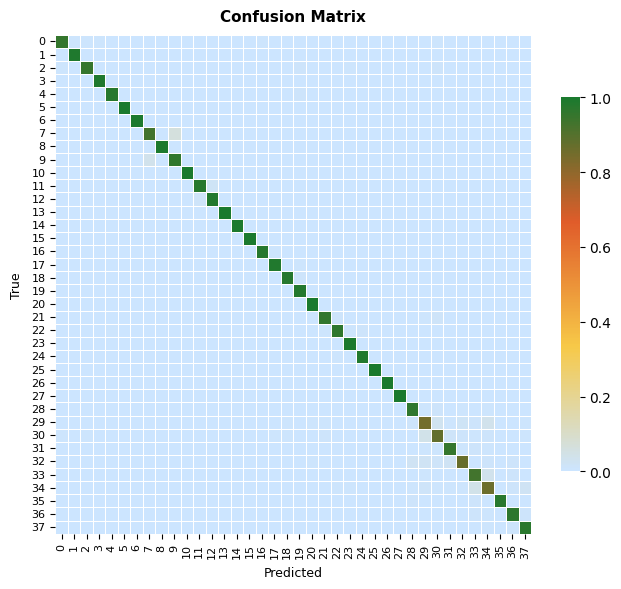


==================================== ROC CURVE ====================================


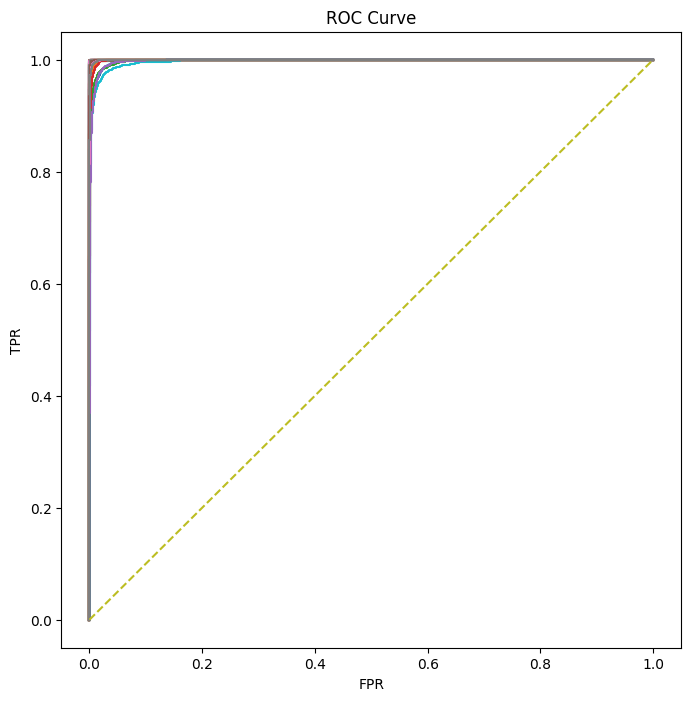

In [8]:
print("TRAINING DATA\n")
train_metrics = evaluate_model(model,train_loader,device,class_names=train_data.classes)

VALIDATION DATA


===== METRICS =====


Metrics,Value
Accuracy,0.955251
Precision,0.955332
Recall,0.954985
F1_Score,0.954940
ROC_AUC,0.999401
Log_loss,0.163834



============================ CONFUSION MATRIX =============================


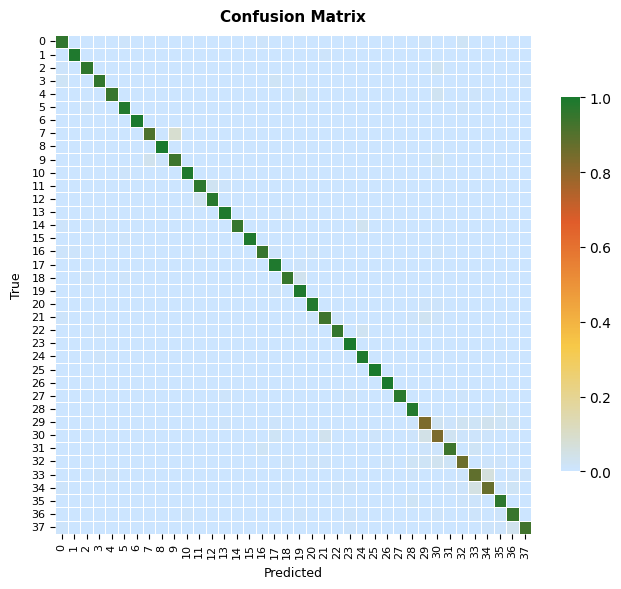


==================================== ROC CURVE ====================================


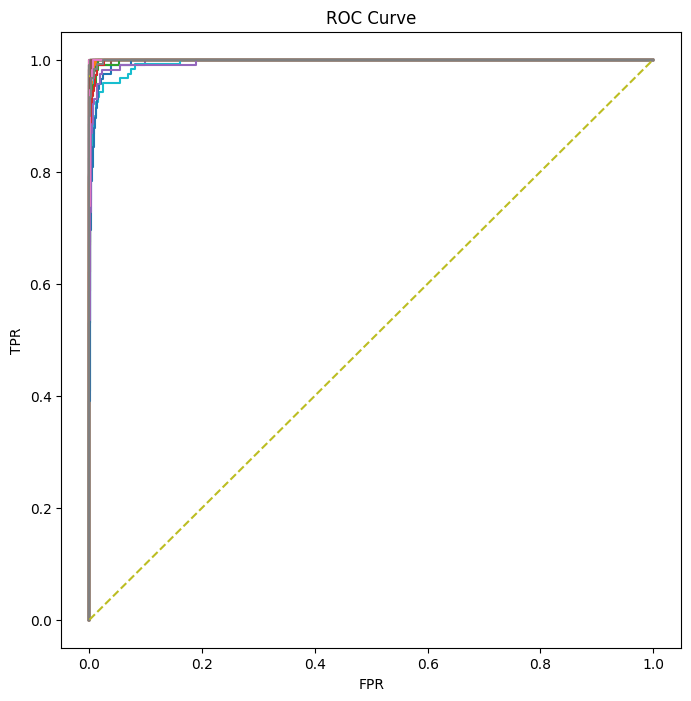

In [9]:
print("VALIDATION DATA\n")
val_metrics = evaluate_model(model,val_loader,device,class_names=train_data.classes)

TESTING DATA


===== METRICS =====


Metrics,Value
Accuracy,0.955672
Precision,0.955264
Recall,0.955507
F1_Score,0.955243
ROC_AUC,0.999447
Log_loss,0.159826



============================ CONFUSION MATRIX =============================


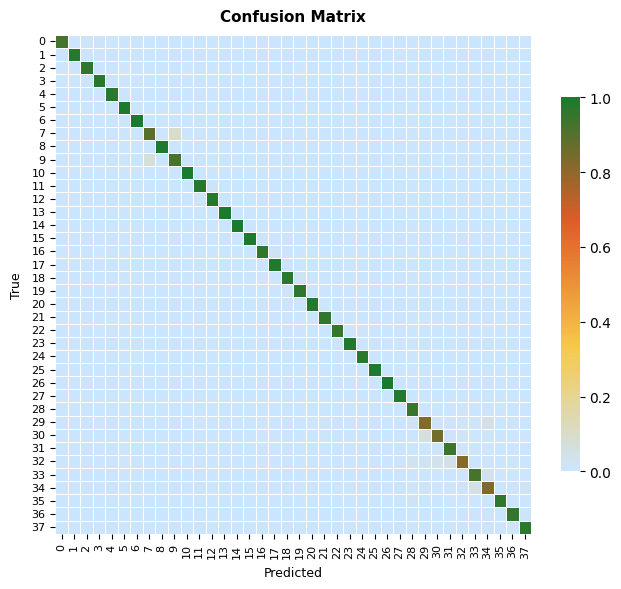


==================================== ROC CURVE ====================================


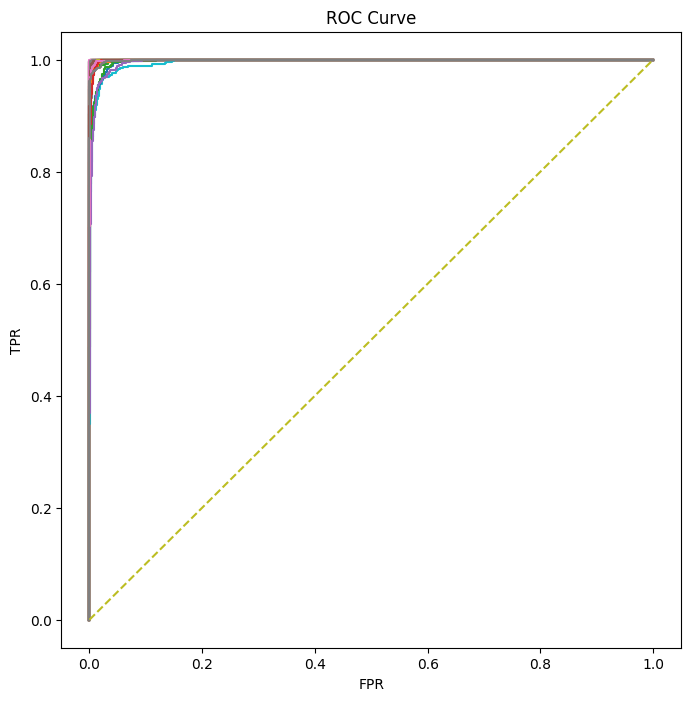

In [10]:
print("TESTING DATA\n")
test_metrics = evaluate_model(model,test_loader,device,class_names=train_data.classes)


================ SPLIT COMPARISON ================


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Log_loss
train,0.9670,0.9667,0.9668,0.9666,0.9997,0.1294
val,0.9553,0.9553,0.9550,0.9549,0.9994,0.1638
test,0.9557,0.9553,0.9555,0.9552,0.9994,0.1598


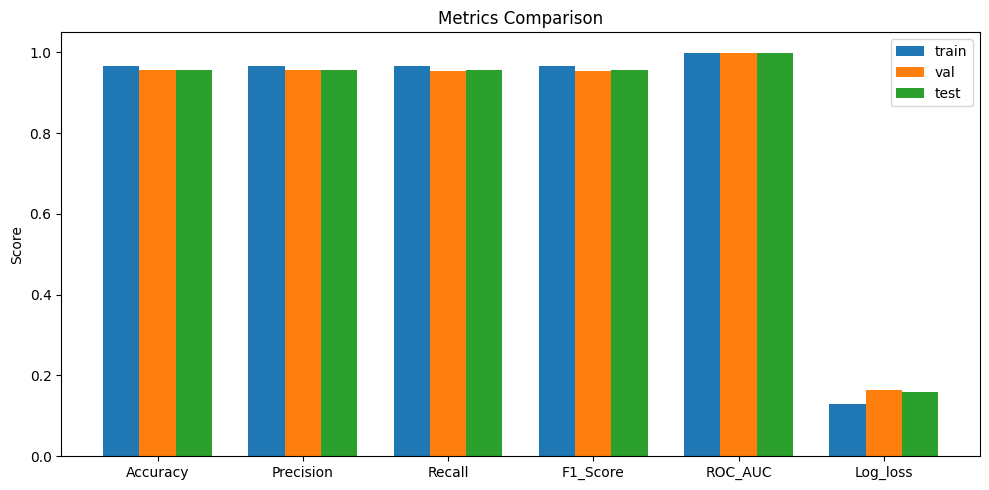

In [11]:
df_comparison=compare_splits(train_metrics,val_metrics,test_metrics)